In [18]:
import numpy as np
import random
import tensorflow as tf

from tensorflow import keras
from keras.models import Sequential
from keras import layers
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

keras.utils.set_random_seed(42)

In [19]:
path = 'Frankenstein.txt'
with open(path, encoding='utf-8') as f:
  text = f.read().lower()
print('Text length:', len(text))
print()
print(text[0:1000])

Text length: 419340

﻿frankenstein;

or, the modern prometheus

by mary wollstonecraft (godwin) shelley


 contents

 letter 1
 letter 2
 letter 3
 letter 4
 chapter 1
 chapter 2
 chapter 3
 chapter 4
 chapter 5
 chapter 6
 chapter 7
 chapter 8
 chapter 9
 chapter 10
 chapter 11
 chapter 12
 chapter 13
 chapter 14
 chapter 15
 chapter 16
 chapter 17
 chapter 18
 chapter 19
 chapter 20
 chapter 21
 chapter 22
 chapter 23
 chapter 24




letter 1

_to mrs. saville, england._


st. petersburgh, dec. 11th, 17—.


you will rejoice to hear that no disaster has accompanied the
commencement of an enterprise which you have regarded with such evil
forebodings. i arrived here yesterday, and my first task is to assure
my dear sister of my welfare and increasing confidence in the success
of my undertaking.

i am already far north of london, and as i walk in the streets of
petersburgh, i feel a cold northern breeze play upon my cheeks, which
braces my nerves and fills me with delight. do you underst

In [20]:
chars = sorted(list(set(text)))

print('total chars:', len(chars))

#from chars to numbers
char_indices = dict((c, i) for i, c in enumerate(chars))
# from numbert to chars
indices_char = dict((i, c) for i, c in enumerate(chars))

print(char_indices)
print(indices_char)

total chars: 61
{'\n': 0, ' ': 1, '!': 2, '(': 3, ')': 4, ',': 5, '-': 6, '.': 7, '0': 8, '1': 9, '2': 10, '3': 11, '4': 12, '5': 13, '6': 14, '7': 15, '8': 16, '9': 17, ':': 18, ';': 19, '?': 20, '[': 21, ']': 22, '_': 23, 'a': 24, 'b': 25, 'c': 26, 'd': 27, 'e': 28, 'f': 29, 'g': 30, 'h': 31, 'i': 32, 'j': 33, 'k': 34, 'l': 35, 'm': 36, 'n': 37, 'o': 38, 'p': 39, 'q': 40, 'r': 41, 's': 42, 't': 43, 'u': 44, 'v': 45, 'w': 46, 'x': 47, 'y': 48, 'z': 49, 'æ': 50, 'è': 51, 'é': 52, 'ê': 53, 'ô': 54, '—': 55, '‘': 56, '’': 57, '“': 58, '”': 59, '\ufeff': 60}
{0: '\n', 1: ' ', 2: '!', 3: '(', 4: ')', 5: ',', 6: '-', 7: '.', 8: '0', 9: '1', 10: '2', 11: '3', 12: '4', 13: '5', 14: '6', 15: '7', 16: '8', 17: '9', 18: ':', 19: ';', 20: '?', 21: '[', 22: ']', 23: '_', 24: 'a', 25: 'b', 26: 'c', 27: 'd', 28: 'e', 29: 'f', 30: 'g', 31: 'h', 32: 'i', 33: 'j', 34: 'k', 35: 'l', 36: 'm', 37: 'n', 38: 'o', 39: 'p', 40: 'q', 41: 'r', 42: 's', 43: 't', 44: 'u', 45: 'v', 46: 'w', 47: 'x', 48: 'y', 49: '

In [21]:
maxlen = 30
step = 2
train_split = int(0.8 * len(text))

text_train = text[:train_split]
text_test = text[train_split:]

print(f"train size: {len(text_train)}")
print(f"test size: {len(text_test)}")

def create_dataset(text, maxlen, p, char_indices, indices_char):
    sentences = []
    next_chars = []
    for i in range(0, len(text) - maxlen, step):
      sentences.append(text[i: i + maxlen])
      next_chars.append(text[i + maxlen])

    x = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.bool)
    y = np.zeros((len(sentences), len(chars)), dtype=np.bool)

    for i, (sentence, next_char) in enumerate(zip(sentences, next_chars)):
        for t, char in enumerate(sentence):
            x[i, t, char_indices[char]] = 1.

        y[i, char_indices[next_char]] = 1.

    return x, y

x_train, y_train = create_dataset(text_train, maxlen, step, char_indices, indices_char)
x_test, y_test = create_dataset(text_test, maxlen, step, char_indices, indices_char)

train size: 335472
test size: 83868


In [22]:
from keras.callbacks import LambdaCallback
import sys

def testAfterEpoch(epoch, _):
  if epoch < 10:
    return
  print()
  print()
  print('----- Generating text after Epoch: %d' % epoch)

  start_index = random.randint(0, len(text)-maxlen-1)

  generated = ''
  sentence = text[start_index: start_index + maxlen]
  generated += sentence
  print('**** starting sentence*****')
  print(sentence)
  print('***************************')
  sys.stdout.write(generated)

  for i in range(200):
    x_pred = np.zeros((1, maxlen, len(chars)))
    for t, char in enumerate(sentence):
      x_pred[0, t, char_indices[char]] = 1
    preds = model.predict(x_pred, verbose=0)[0]
    next_index = np.argmax(preds)
    next_char = indices_char[next_index]

    sentence = sentence[1:] + next_char
    sys.stdout.write(next_char)
    sys.stdout.flush()
  print()

print_callback = LambdaCallback(on_epoch_end=testAfterEpoch)

# CNN

In [23]:
model = keras.Sequential([
    keras.Input(shape=(maxlen, len(chars), 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(len(chars), activation="softmax"),
])

optimizer = keras.optimizers.RMSprop(learning_rate=0.01)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 59, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 29, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 13, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4992)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4992)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 61)             │       304,573 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,389 (1.23 MB)

 Trainable params: 323,389 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(x_train,y_train,
          batch_size=2048,
          epochs=30,
          callbacks = [print_callback],
          validation_data=(x_test, y_test))

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - accuracy: 0.1309 - loss: 3.2488 - val_accuracy: 0.1713 - val_loss: 2.9264
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.1707 - loss: 2.9186 - val_accuracy: 0.2102 - val_loss: 2.7654
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.1954 - loss: 2.8163 - val_accuracy: 0.2286 - val_loss: 2.6973
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.2087 - loss: 2.7699 - val_accuracy: 0.2502 - val_loss: 2.6847
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.2154 - loss: 2.7404 - val_accuracy: 0.2569 - val_loss: 2.6266
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.2195 - loss: 2.7195 - val_accuracy: 0.2617 - val_loss: 2.6438
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.2222 - loss: 2.7134 - val_accuracy: 0.2635 - val_loss: 2.5952
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.2279 - loss: 2.6991 - val_accuracy: 0.2597 

In [25]:
score = model.evaluate(x_test, y_test, verbose=0) #input, label, verbose
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 2.533277988433838
Test accuracy 0.2936854362487793


In [26]:
import matplotlib.pyplot as plt
def plot_performance(history, title):
  fig, ax = plt.subplots(1, 2, figsize=(10, 5))
  fig.tight_layout(pad=3.0)
  plt.suptitle(title)
  train_acc = history.history['accuracy']
  valid_acc = history.history['val_accuracy']
  train_loss = history.history['loss']
  valid_loss = history.history['val_loss']
  ax[0].set_xlabel('Epoch')
  ax[0].set_ylabel('Loss')
  ax[0].set_title('Loss')
  ax[0].plot(train_loss, label='Training Loss')
  ax[0].plot(valid_loss, label='Validation Loss')
  ax[0].legend()
  ax[1].set_title('Accuracy')
  ax[1].set_xlabel('Epoch')
  ax[1].set_ylabel('Accuracy')
  ax[1].plot(train_acc, label='Training Accuracy')
  ax[1].plot(valid_acc, label='Validation Accuracy')
  ax[1].legend()
  plt.show()

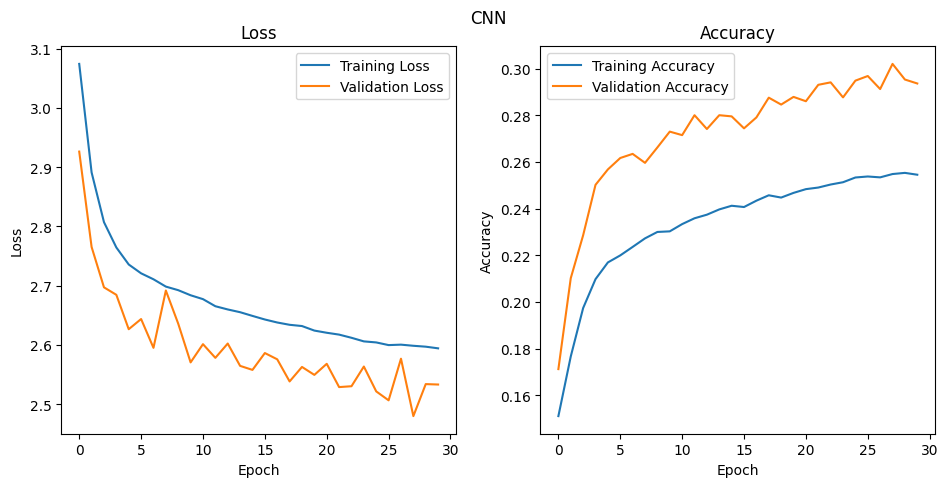

In [27]:
plot_performance(history, "CNN")

# RNN 1

In [28]:
model_rnn = keras.Sequential([
    keras.Input(shape=(maxlen, len(chars))),
    LSTM(128, return_sequences=True), # Nota: return_sequences=True qui!
    Dropout(0.4),
    LSTM(128),
    Dropout(0.4),
    Dense(len(chars), activation="softmax")
])

optimizer_rnn = keras.optimizers.RMSprop(learning_rate=0.01)
model_rnn.compile(loss='categorical_crossentropy', optimizer=optimizer_rnn, metrics=['accuracy'])

model_rnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 30, 128)        │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,733 (924.74 KB)

 Trainable params: 236,733 (924.74 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_rnn = model_rnn.fit(x_train, y_train,
          batch_size=2048,
          epochs=30,
          callbacks = [print_callback],
          validation_data=(x_test, y_test))

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.1458 - loss: 3.1869 - val_accuracy: 0.2565 - val_loss: 2.6092
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.2605 - loss: 2.5720 - val_accuracy: 0.3234 - val_loss: 2.2938
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.3152 - loss: 2.3453 - val_accuracy: 0.3676 - val_loss: 2.1144
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.3521 - loss: 2.2128 - val_accuracy: 0.3935 - val_loss: 2.0306
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.3736 - loss: 2.1188 - val_accuracy: 0.4158 - val_loss: 1.9437
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.3958 - loss: 2.0319 - val_accuracy: 0.4346 - val_loss: 1.8677
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.4130 - loss: 1.9640 - val_accuracy: 0.4440 - val_loss: 1.8163
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.4274 - loss: 1.9151 - val_accuracy: 0.4566 - v

In [30]:
score = model_rnn.evaluate(x_test, y_test, verbose=0) #input, label, verbose
print("Test loss", score[0])
print("Test accuracy", score[1])

Test loss 1.4765405654907227
Test accuracy 0.5487249493598938


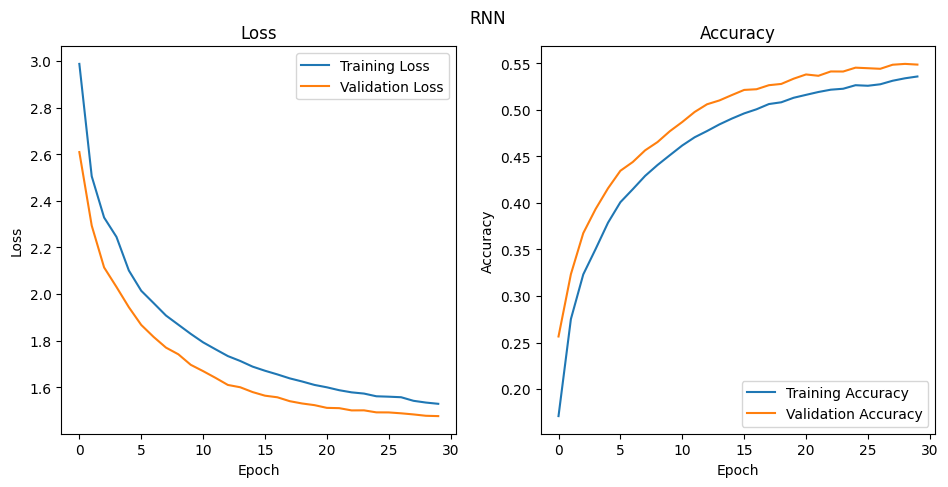

In [31]:
plot_performance(history_rnn, "RNN")

# RNN 2

In [40]:
model2_rnn = keras.Sequential([
    keras.Input(shape=(maxlen, len(chars))),
    LSTM(128, return_sequences=True), # Nota: return_sequences=True qui!
    Dropout(0.5),
    LSTM(128),
    Dropout(0.5),
    Dense(len(chars), activation="softmax")
])

optimizer_rnn = keras.optimizers.RMSprop(learning_rate=0.01)
model2_rnn.compile(loss='categorical_crossentropy', optimizer=optimizer_rnn, metrics=['accuracy'], run_eagerly=True) # <--- Importante!

model2_rnn.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 30, 128)        │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,733 (924.74 KB)

 Trainable params: 236,733 (924.74 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history2_rnn = model2_rnn.fit(x_train, y_train,
          batch_size=2048,
          epochs=100,
          callbacks=[print_callback, early_stopping],
          validation_data=(x_test, y_test))

Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.1420 - loss: 3.1873 - val_accuracy: 0.2569 - val_loss: 2.6064
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - accuracy: 0.2542 - loss: 2.6374 - val_accuracy: 0.3198 - val_loss: 2.2965
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 108ms/step - accuracy: 0.3119 - loss: 2.3735 - val_accuracy: 0.3432 - val_loss: 2.1876
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - accuracy: 0.3449 - loss: 2.2278 - val_accuracy: 0.3931 - val_loss: 2.0235
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.3709 - loss: 2.1291 - val_accuracy: 0.4196 - val_loss: 1.9304
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step - accuracy: 0.3931 - loss: 2.0525 - val_accuracy: 0.4307 - val_loss: 1.8764
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.4073 - loss: 1.9976 - val_accuracy: 0.4450 - val_loss: 1.8135
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.4197 - loss: 1.9450 - val_

In [42]:
score2 = model2_rnn.evaluate(x_test, y_test, verbose=0) #input, label, verbose
print("Test loss", score2[0])
print("Test accuracy", score2[1])

Test loss 1.4449784755706787
Test accuracy 0.5627758502960205


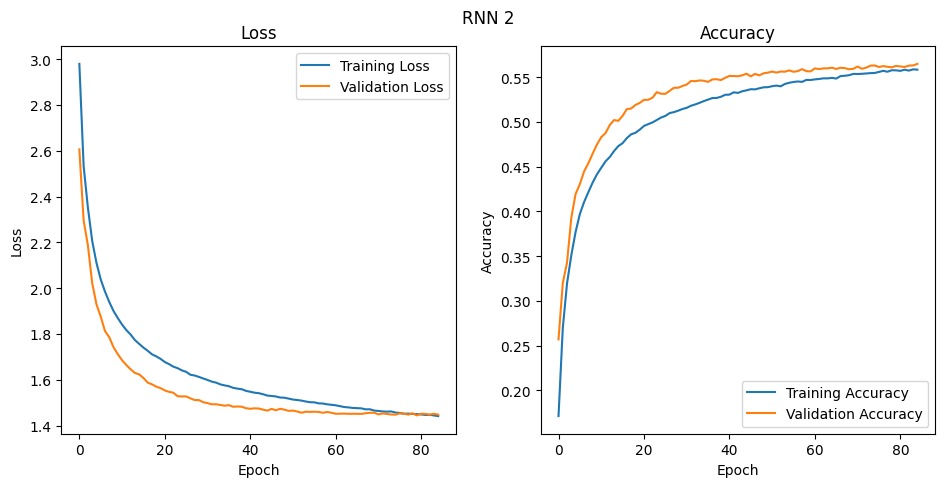

In [43]:
plot_performance(history2_rnn, "RNN 2")